# This is the Notebook for Data Quality Report 

#### All the findings that are connected to it. It is using the database of California wildfire accident. It is divided into 4 parts, where each part is highlighted and explained

## **PART 1**

### Preparation of data for Data Quality Report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

### Display all the columns, read the dataset, check shape of the dataset, convert different types of features

In [2]:
# display all columns 
pd.set_option('display.max_columns', None)

In [3]:
# read data from cvs into panda dataframe
df = pd.read_csv('cal-wildfires-24231301-original.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)

In [4]:
# check shape of CSV file
df.shape

(10000, 33)

In [5]:
# print the first 5 rows
df.head(5)

,OBJECTID,* Damage,* Street Number,* Street Name,"* Street Type (e.g. road, drive, lane, etc.)",* City,State,Zip Code,* CAL FIRE Unit,County,Community,Incident Start Date,Hazard Type,Structure Defense Actions Taken,* Structure Type,Structure Category,# Units in Structure (if multi unit),* Roof Construction,* Eaves,* Vent Screen,* Exterior Siding,* Window Pane,* Deck/Porch On Grade,* Deck/Porch Elevated,* Patio Cover/Carport Attached to Structure,* Fence Attached to Structure,Distance - Propane Tank to Structure,Distance - Residence to Utility/Misc Structure &gt; 120 SQFT,Assessed Improved Value (parcel),Year Built (parcel),Site Address (parcel),Latitude,Longitude
0,1249,Destroyed (>50%),28615.0,North Highway 101,Other,Willits,CA,NaN,MEU,Mendocino,Ryan Creek,9/7/2020 12:00:00 AM,Fire,Unknown,Utility Misc Structure,Other Minor Structure,NaN,Unknown,No Eaves,No Vents,Wood,Single Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,NaN,NaN,NaN,NaN,NaN,39.483762,-123.360442
1,114904,No Damage,1534.0,Morada,Place,Altadena,CA,91001.0,LAC,Los Angeles,NaN,1/7/2025 8:02:01 AM,Fire,Unknown,Utility Misc Structure,Other Minor Structure,0.0,Tile,No Eaves,No Vents,Stucco Brick Cement,Single Pane,Masonry/Concrete,No Deck/Porch,No Patio Cover/Carport,Combustible,NaN,30-50',478038.0,NaN,"1534 MORADA PL, ALTADENA, CA 91001",34.179046,-118.118848
2,33819,Destroyed (>50%),1852.0,Merrill,Road,Paradise Northeast B,CA,NaN,BTU,Butte,Paradise,11/8/2018 12:00:00 AM,Fire,Unknown,Single Family Residence Single Story,Single Residence,NaN,Asphalt,Enclosed,"Mesh Screen <= 1/8""""",Ignition Resistant,Multi Pane,Masonry/Concrete,Wood,Combustible,Combustible,NaN,<30',82100.0,1977.0,1852 MERRILL RD PARADISE CA 95969,39.781229,-121.573907
3,49965,Destroyed (>50%),29685.0,Cuthbert,Road,Malibu,CA,NaN,LAC,Los Angeles,Malibu,11/8/2018 12:00:00 AM,Fire,Unknown,Utility Misc Structure,Other Minor Structure,1.0,Metal,No Eaves,No Vents,Ignition Resistant,Unknown,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,NaN,>50',1003681.0,1978.0,29685 CUTHBERT RD MALIBU CA 90265,34.034050,-118.820568
4,55152,No Damage,NaN,NaN,NaN,Unincorporated,CA,NaN,BTU,Butte,NaN,11/8/2018 12:00:00 AM,Fire,NaN,Single Family Residence Single Story,Single Residence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,259143.0,2000.0,3445 SUNVIEW DR PARADISE CA 95969,39.676937,-121.571119


In [6]:
# print the last 5 rows
df.tail(5)

,OBJECTID,* Damage,* Street Number,* Street Name,"* Street Type (e.g. road, drive, lane, etc.)",* City,State,Zip Code,* CAL FIRE Unit,County,Community,Incident Start Date,Hazard Type,Structure Defense Actions Taken,* Structure Type,Structure Category,# Units in Structure (if multi unit),* Roof Construction,* Eaves,* Vent Screen,* Exterior Siding,* Window Pane,* Deck/Porch On Grade,* Deck/Porch Elevated,* Patio Cover/Carport Attached to Structure,* Fence Attached to Structure,Distance - Propane Tank to Structure,Distance - Residence to Utility/Misc Structure &gt; 120 SQFT,Assessed Improved Value (parcel),Year Built (parcel),Site Address (parcel),Latitude,Longitude
9995,82144,No Damage,17620.0,Strawberry,Lane,Twin Bridges,CA,95735.0,AEU,El Dorado,Strawberry,8/14/2021 12:00:00 AM,Fire,Unknown,Utility Misc Structure,Other Minor Structure,0.0,Metal,Unenclosed,No Vents,Wood,Multi Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,NaN,NaN,302790.0,NaN,17620 STRAWBERRY LN TWIN BRIDGES CA 95735,38.800028,-120.141912
9996,82145,No Damage,28.0,Pyramid Creek Tract,Other,NaN,CA,NaN,AEU,El Dorado,NaN,8/14/2021 12:00:00 AM,Fire,NaN,Single Family Residence Multi Story,Single Residence,0.0,Metal,No Eaves,No Vents,Wood,Single Pane,No Deck/Porch,Wood,No Patio Cover/Carport,No Fence,NaN,NaN,NaN,NaN,NaN,38.808079,-120.137545
9997,13292,No Damage,900.0,Wildwood,Trail,NaN,CA,NaN,LNU,Sonoma,NaN,9/27/2020 12:00:00 AM,Fire,NaN,Single Family Residence Single Story,Single Residence,NaN,Asphalt,Enclosed,"Mesh Screen > 1/8""""",Stucco Brick Cement,Multi Pane,Masonry/Concrete,No Deck/Porch,No Patio Cover/Carport,No Fence,NaN,NaN,714108.0,1966.0,900 WILDWOOD TRL SANTA ROSA CA 95409,38.465873,-122.622171
9998,27444,No Damage,5455.0,Camino De Bryant,NaN,NaN,CA,NaN,ORC,Orange,NaN,10/26/2020 12:00:00 AM,Fire,NaN,Single Family Residence Multi Story,Single Residence,NaN,Tile,Unenclosed,No Vents,Stucco Brick Cement,Multi Pane,Masonry/Concrete,No Deck/Porch,No Patio Cover/Carport,Non Combustible,NaN,NaN,530679.0,1992.0,5455 CAMINO DE BRYANT YORBA LINDA CA 92887,33.888719,-117.711565
9999,63703,Destroyed (>50%),3508.0,Brookdale,Drive,Santa Rosa,CA,0.0,LNU,Sonoma,Fountaingrove,10/8/2017 12:00:00 AM,Fire,NaN,Single Family Residence Single Story,Single Residence,NaN,Fire Resistant,Enclosed,Screened,Fire Resistant,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,111121.0,NaN,3508 BROOKDALE DR SANTA ROSA CA 95404,38.478798,-122.702129


In [7]:
# convert features to appropriate datatypes
df.dtypes

OBJECTID                                                          int64
* Damage                                                         object
* Street Number                                                 float64
* Street Name                                                    object
* Street Type (e.g. road, drive, lane, etc.)                     object
* City                                                           object
State                                                            object
Zip Code                                                        float64
* CAL FIRE Unit                                                  object
County                                                           object
Community                                                        object
Incident Start Date                                              object
Hazard Type                                                      object
Structure Defense Actions Taken                                 

In [8]:
# Clean column names: Remove leading/trailing spaces, replace spaces with underscores, and remove special characters
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)

In [9]:
# Select categorical columns based on known categorical features
categorical_columns = df[['_Damage', '_Street_Name', '_Street_Number', '_Street_Type_eg_road_drive_lane_etc', '_City', 'State', 'Zip_Code', '_CAL_FIRE_Unit',
                          'County', 'Community', 'Hazard_Type', 'Structure_Defense_Actions_Taken',
                          'Structure_Category', '_Roof_Construction', '_Eaves',
                          '_Vent_Screen', '_Exterior_Siding', '_Window_Pane', '_DeckPorch_On_Grade',
                          '_DeckPorch_Elevated', '_Patio_CoverCarport_Attached_to_Structure',
                          '_Fence_Attached_to_Structure', 'Site_Address_parcel']]

# These columns were chosen as categorical because they contain descriptive values 
# representing different classes rather than numerical data.

# Convert selected columns to categorical data type
for column in categorical_columns:
    df[column] = df[column].astype('category')

# Select continuous features based on numeric data types
continuous_features = df.select_dtypes(['int64', 'float64']).columns  


In [10]:
# Turn the feature 'ID' from 'int64' to 'category' type
df['OBJECTID'] = df['OBJECTID'].astype('category')

In [11]:
# Display data types to verify changes
df.dtypes

OBJECTID                                                    category
_Damage                                                     category
_Street_Number                                              category
_Street_Name                                                category
_Street_Type_eg_road_drive_lane_etc                         category
_City                                                       category
State                                                       category
Zip_Code                                                    category
_CAL_FIRE_Unit                                              category
County                                                      category
Community                                                   category
Incident_Start_Date                                           object
Hazard_Type                                                 category
Structure_Defense_Actions_Taken                             category
_Structure_Type                   

### Check for duplicate columns

In [12]:
# Check for duplicate columns
dfT = df.T
print("Number of duplicate (excluding first) columns in the table is: ", dfT.duplicated().sum())
print("Number of duplicate (including first) columns in the table is: ",  dfT[dfT.duplicated(keep=False)].shape[0])

Number of duplicate (excluding first) columns in the table is:  0
Number of duplicate (including first) columns in the table is:  0


In [13]:
# Identify constant columns - unique value
constant_columns = df.columns[df.nunique() == 1]

# Display the constant columns
print("Constant Columns:", constant_columns)

# Display the constant columns' values
print("Values in Constant Columns:")
print(df[constant_columns].head()) 



Constant Columns: Index(['State', 'Hazard_Type'], dtype='object')
Values in Constant Columns:
  State Hazard_Type
0    CA        Fire
1    CA        Fire
2    CA        Fire
3    CA        Fire
4    CA        Fire


In this dataset, there are only 2 columns with constant - repetitive values, which is the State and Hazard Type. In this dataset it makes sense to drop these 2 columns in the future, as they indicate 2 obvious values. State - the fire only was in the state of California and Hazard type - this dataset is making assumptions about the consequences of a fire hazard type.

### Descriptive Statistics Tables for Continuous and Categorical features

In [14]:
# Print table with categorical statistics
df.select_dtypes(['category']).describe().T

,count,unique,top,freq
OBJECTID,10000,10000,131541,1
_Damage,10000,2,Destroyed (>50%),5807
_Street_Number,9670.0,5684.0,0.0,520.0
_Street_Name,9594,4010,Pentz,73
_Street_Type_eg_road_drive_lane_etc,8923,23,Road,3474
_City,7552,250,Unincorporated,1217
State,9999,1,CA,9999
Zip_Code,5935.0,148.0,0.0,1898.0
_CAL_FIRE_Unit,10000,27,LAC,2597
County,9998,45,Los Angeles,2597


In [15]:
#Look at the categorical features only
category_columns = df.select_dtypes(['category']).columns
df_categorical = df[category_columns]

In [16]:
# Add cardinality column
numeric_columns_card = df[category_columns].nunique()

# Store the values in a DataFrame
df_numeric_card = pd.DataFrame(numeric_columns_card, columns=['card'])

# Print the table for cardinality (number of unique values)
print("Cardinality Table:\n", df_numeric_card)

Cardinality Table:
                                             card
OBJECTID                                   10000
_Damage                                        2
_Street_Number                              5684
_Street_Name                                4010
_Street_Type_eg_road_drive_lane_etc           23
_City                                        250
State                                          1
Zip_Code                                     148
_CAL_FIRE_Unit                                27
County                                        45
Community                                    420
Hazard_Type                                    1
Structure_Defense_Actions_Taken               10
Structure_Category                             6
_Roof_Construction                             9
_Eaves                                         5
_Vent_Screen                                   6
_Exterior_Siding                              10
_Window_Pane                                   4


In [17]:
# Calculate percentage of missing values for categorical columns
df_category_perc_missing = df[category_columns].isnull().mean() * 100

# Convert to DataFrame for consistency
df_category_perc_missing = df_category_perc_missing.to_frame(name='perc_missing')

# Print the table for percentage of missing values
print("Percentage of Missing Values:\n", df_category_perc_missing)


Percentage of Missing Values:
                                            perc_missing
OBJECTID                                           0.00
_Damage                                            0.00
_Street_Number                                     3.30
_Street_Name                                       4.06
_Street_Type_eg_road_drive_lane_etc               10.77
_City                                             24.48
State                                              0.01
Zip_Code                                          40.65
_CAL_FIRE_Unit                                     0.00
County                                             0.02
Community                                         57.70
Hazard_Type                                        0.00
Structure_Defense_Actions_Taken                   72.76
Structure_Category                                 0.00
_Roof_Construction                                 3.53
_Eaves                                             3.91
_Vent_Screen     

In [18]:
# Continuous features table summary 

df_continuous = ['Incident_Start_Date', '_Units_in_Structure_if_multi_unit', 'Distance__Propane_Tank_to_Structure', 'Distance__Residence_to_UtilityMisc_Structure_gt_120_SQFT',
                      'Assessed_Improved_Value_parcel', 'Year_Built_parcel', 'Latitude', 'Longitude', '_Damage']

df[df_continuous].head(5)

,Incident_Start_Date,_Units_in_Structure_if_multi_unit,Distance__Propane_Tank_to_Structure,Distance__Residence_to_UtilityMisc_Structure_gt_120_SQFT,Assessed_Improved_Value_parcel,Year_Built_parcel,Latitude,Longitude,_Damage
0,9/7/2020 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,39.483762,-123.360442,Destroyed (>50%)
1,1/7/2025 8:02:01 AM,0.0,NaN,30-50',478038.0,NaN,34.179046,-118.118848,No Damage
2,11/8/2018 12:00:00 AM,NaN,NaN,<30',82100.0,1977.0,39.781229,-121.573907,Destroyed (>50%)
3,11/8/2018 12:00:00 AM,1.0,NaN,>50',1003681.0,1978.0,34.034050,-118.820568,Destroyed (>50%)
4,11/8/2018 12:00:00 AM,NaN,NaN,NaN,259143.0,2000.0,39.676937,-121.571119,No Damage


In [19]:
# For each continuous feature, we display the range of values it takes.
# We also display the number of instances each of its values has.

for feature in continuous_features:
    print(feature)
    print("----------\n")

    # Check if the column is categorical
    if pd.api.types.is_categorical_dtype(df[feature]):
        df[feature] = df[feature].cat.as_ordered()

    print("Range {} is: ".format(feature), (df[feature].max() - df[feature].min()))
    print("----------")
    print('{0:.5}  {1}'.format("Value", "Number of Instances"))
    print(df[feature].value_counts().nlargest(15), "\n\n\n")


OBJECTID
----------

Range OBJECTID is:  131828
----------
Value  Number of Instances
OBJECTID
131541    1
131537    1
131500    1
131480    1
131462    1
131454    1
131419    1
131410    1
131357    1
131356    1
131355    1
131337    1
131335    1
131328    1
131322    1
Name: count, dtype: int64 



_Units_in_Structure_if_multi_unit
----------

Range _Units_in_Structure_if_multi_unit is:  80.0
----------
Value  Number of Instances
_Units_in_Structure_if_multi_unit
0.0     2751
1.0      122
2.0       53
4.0       26
3.0       23
8.0       13
6.0        9
10.0       9
7.0        7
9.0        4
5.0        3
20.0       2
40.0       1
80.0       1
Name: count, dtype: int64 



Assessed_Improved_Value_parcel
----------

Range Assessed_Improved_Value_parcel is:  387260001.0
----------
Value  Number of Instances
Assessed_Improved_Value_parcel
0.0           408
54139901.0     24
60393.0        21
2756731.0      13
140000.0       12
20000.0        11
120000.0       10
150000.0       10
50000

C:\Users\ragul\AppData\Local\Temp\ipykernel_2796\4110906512.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[feature]):
C:\Users\ragul\AppData\Local\Temp\ipykernel_2796\4110906512.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[feature]):


In [20]:
# Display the cardinality of each continuous feature

features_cardinality = list(df[continuous_features].columns.values)

print('{0:35}  {1}'.format("Feature", "Cardinality"))
print('{0:35}  {1}'.format("-------", "--------------- \n"))

for c in features_cardinality:
    print('{0:35}  {1}'.format(c, str(len(df[c].unique()))))

Feature                              Cardinality
-------                              --------------- 

OBJECTID                             10000
_Units_in_Structure_if_multi_unit    15
Assessed_Improved_Value_parcel       7618
Year_Built_parcel                    141
Latitude                             9993
Longitude                            9996


In [21]:
# Descriptive stats for continuous features
pd.set_option("display.precision", 3)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
_Units_in_Structure_if_multi_unit,3024.0,0.301,2.016e+00,0.00,0.000,0.000,0.000,8.000e+01
Assessed_Improved_Value_parcel,9477.0,691595.909,6.358e+06,0.00,69151.000,159866.000,342085.000,3.873e+08
Year_Built_parcel,7563.0,1757.238,6.049e+02,0.00,1940.000,1962.000,1983.000,2.022e+03
Latitude,10000.0,37.379,2.490e+00,32.60,34.196,38.476,39.744,4.195e+01
Longitude,10000.0,-120.539,1.823e+00,-123.47,-122.139,-121.455,-118.539,-1.164e+02


In [22]:
# Prepare % missing column for continuous features
numeric_columns_missing = 100 * (df[continuous_features].isnull().sum() / df.shape[0])

# Store the values in a dataframe
df_numeric_missing = pd.DataFrame(numeric_columns_missing, columns=['%missing'])

df_numeric_missing


,%missing
OBJECTID,0.00
_Units_in_Structure_if_multi_unit,69.76
Assessed_Improved_Value_parcel,5.23
Year_Built_parcel,24.37
Latitude,0.00
Longitude,0.00


### LOGICAL TESTS

Performing logical tests for each column to test how many missing data can be found

In [23]:
# multi unit buildings should have more than 1 unit
test_units = df[['_Structure_Type', '_Units_in_Structure_if_multi_unit']][
    (df['_Structure_Type'] == 'Multi-unit') & (df['_Units_in_Structure_if_multi_unit'] <= 1)
]
print("Number of rows failing the Multi-unit test:", test_units.shape[0])
test_units.head()


Number of rows failing the Multi-unit test: 0


,_Structure_Type,_Units_in_Structure_if_multi_unit


In [24]:
# distance from propane tank to the building
test_distance = df[['Distance__Propane_Tank_to_Structure']][df['Distance__Propane_Tank_to_Structure'].isna()]
print("Number of rows failing the Distance test (NaN):", test_distance.shape[0])
test_distance.head()


Number of rows failing the Distance test (NaN): 8156


,Distance__Propane_Tank_to_Structure
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [25]:
# test how many year built parcel has 0 or string values

test_year = df[['Year_Built_parcel']][df['Year_Built_parcel'].isna() | (df['Year_Built_parcel'] == 0)]
print("Number of rows failing the Year Built test (0 or NaN):", test_year.shape[0])
test_year.head()


Number of rows failing the Year Built test (0 or NaN): 3236


,Year_Built_parcel
0,NaN
1,NaN
6,0.0
7,NaN
9,0.0


In [26]:
# assessed values not negative
test_value = df[['Assessed_Improved_Value_parcel']][df['Assessed_Improved_Value_parcel'] < 0]
print("Number of rows failing the Assessed Value test:", test_value.shape[0])
test_value.head()


Number of rows failing the Assessed Value test: 0


,Assessed_Improved_Value_parcel


In [27]:
# street number should not be null if street name is provided
test_street = df[['_Street_Number', '_Street_Name']][df['_Street_Name'].notnull() & df['_Street_Number'].isnull()]
print("Number of rows failing the Street Number test:", test_street.shape[0])
test_street.head()


Number of rows failing the Street Number test: 24


,_Street_Number,_Street_Name
94,NaN,Yankee Vista
1020,NaN,Lobo Canyon
1362,NaN,Sawmill
1461,NaN,Rock Creek
2337,NaN,French Gulch


In [28]:
#zip code format
df['Zip_Code'] = pd.to_numeric(df['Zip_Code'], errors='coerce')

test_zip_format = df[['Zip_Code']][df['Zip_Code'].notnull() & ((df['Zip_Code'] < 10000) | (df['Zip_Code'] > 99999))]
print("Number of rows failing the Zip Code format test:", test_zip_format.shape[0])
test_zip_format.head()

Number of rows failing the Zip Code format test: 1898


,Zip_Code
6,0.0
12,0.0
15,0.0
20,0.0
22,0.0


In [29]:
# structure category is NaN or empty
test_structure_category = df[['Structure_Category']][df['Structure_Category'].isna() | (df['Structure_Category'] == '')]
print("Number of rows failing the Structure Category test (NaN or empty):", test_structure_category.shape[0])
test_structure_category.head()


Number of rows failing the Structure Category test (NaN or empty): 0


,Structure_Category


In [30]:
# hazard type should not be null if damage is reported
test_hazard_damage = df[['_Damage', 'Hazard_Type']][df['_Damage'].notnull() & df['Hazard_Type'].isnull()]
print("Number of rows failing the Hazard Type test:", test_hazard_damage.shape[0])
test_hazard_damage.head()


Number of rows failing the Hazard Type test: 0


,_Damage,Hazard_Type


In [31]:
# latitude should be between -90 and 90, longitude between -180 and 180
test_geo_range = df[['Latitude', 'Longitude']][
    (df['Latitude'] < -90) | (df['Latitude'] > 90) | (df['Longitude'] < -180) | (df['Longitude'] > 180)
]
print("Number of rows failing the Geospatial Range test:", test_geo_range.shape[0])
test_geo_range.head()


Number of rows failing the Geospatial Range test: 0


,Latitude,Longitude


In [32]:
# roof construction
test_roof_construction = df[df['_Roof_Construction'].isnull() | (df['_Roof_Construction'] == '')]
print("Number of rows failing the Roof Construction test:", test_roof_construction.shape[0])


Number of rows failing the Roof Construction test: 353


In [33]:
# distance residence to utility
test_distance_residence = df[df['Distance__Residence_to_UtilityMisc_Structure_gt_120_SQFT'].isnull()]
print("Number of rows failing the Distance to Residence test:", test_distance_residence.shape[0])


Number of rows failing the Distance to Residence test: 8527


In [34]:
# window pane
test_window_pane = df[df['_Window_Pane'].isnull() | (df['_Window_Pane'] == '')]
print("Number of rows failing the Window Pane test:", test_window_pane.shape[0])

Number of rows failing the Window Pane test: 377


In [35]:
# Test: Roof Construction should not be null
test_roof_construction_nulls = df[df['_Roof_Construction'].isnull()]
print("Number of rows failing the Roof Construction (null) test:", test_roof_construction_nulls.shape[0])

Number of rows failing the Roof Construction (null) test: 353


In [36]:
# Test: Deck/Porch On Grade should not be null
test_deck_on_grade_nulls = df[df['_DeckPorch_On_Grade'].isnull()]
print("Number of rows failing the Deck/Porch On Grade (null) test:", test_deck_on_grade_nulls.shape[0])

# Test: Deck/Porch Elevated should not be null
test_deck_elevated_nulls = df[df['_DeckPorch_Elevated'].isnull()]
print("Number of rows failing the Deck/Porch Elevated (null) test:", test_deck_elevated_nulls.shape[0])


Number of rows failing the Deck/Porch On Grade (null) test: 1632
Number of rows failing the Deck/Porch Elevated (null) test: 1632


In [37]:
test_structure_type = df[df['_Structure_Type'].isnull() | (df['_Structure_Type'] == '')]
print("Number of rows failing the Structure Type test:", test_structure_type.shape[0])

Number of rows failing the Structure Type test: 0


In [38]:
# fence attached to building
test_fence = df[df['_Fence_Attached_to_Structure'].isnull()]
print("Number of rows failing the Fence Attached to Structure test:", test_fence.shape[0])


Number of rows failing the Fence Attached to Structure test: 1632


In [39]:
# Damage should not be null
test_damage_nulls = df[df['_Damage'].isnull()]
print("Number of rows failing the Damage (null) test:", test_damage_nulls.shape[0])

Number of rows failing the Damage (null) test: 0


In [40]:
# Test: _CAL_FIRE_Unit should not be null
test_cal_fire_unit_nulls = df[df['_CAL_FIRE_Unit'].isnull()]
print("Number of rows failing the CAL FIRE Unit (null) test:", test_cal_fire_unit_nulls.shape[0])

Number of rows failing the CAL FIRE Unit (null) test: 0


In [41]:
# Test: Structure_Defense_Actions_Taken should not be null
test_structure_defense_nulls = df[df['Structure_Defense_Actions_Taken'].isnull()]
print("Number of rows failing the Structure Defense Actions Taken (null) test:", test_structure_defense_nulls.shape[0])

Number of rows failing the Structure Defense Actions Taken (null) test: 7276


In [42]:
# Test: Structure_Category should not be null
test_structure_category_nulls = df[df['Structure_Category'].isnull()]
print("Number of rows failing the Structure Category (null) test:", test_structure_category_nulls.shape[0])

Number of rows failing the Structure Category (null) test: 0


In [43]:
# Test: _Eaves should not be null
test_eaves_nulls = df[df['_Eaves'].isnull()]
print("Number of rows failing the Eaves (null) test:", test_eaves_nulls.shape[0])

Number of rows failing the Eaves (null) test: 391


In [44]:
# Test: _Vent_Screen should not be null
test_vent_screen_nulls = df[df['_Vent_Screen'].isnull()]
print("Number of rows failing the Vent Screen (null) test:", test_vent_screen_nulls.shape[0])

Number of rows failing the Vent Screen (null) test: 397


In [45]:
# Test: _Exterior_Siding should not be null
test_exterior_siding_nulls = df[df['_Exterior_Siding'].isnull()]
print("Number of rows failing the Exterior Siding (null) test:", test_exterior_siding_nulls.shape[0])

Number of rows failing the Exterior Siding (null) test: 370


In [46]:
# Test: _Patio_CoverCarport_Attached_to_Structure should not be null
test_patio_cover_nulls = df[df['_Patio_CoverCarport_Attached_to_Structure'].isnull()]
print("Number of rows failing the Patio Cover/Carport Attached to Structure (null) test:", test_patio_cover_nulls.shape[0])

Number of rows failing the Patio Cover/Carport Attached to Structure (null) test: 1632


In [47]:
# Zip codes if they are presented if State is filled
test_zip = df[['State', 'Zip_Code']][df['State'].notnull() & df['Zip_Code'].isnull()]
print("Number of rows failing the Zip Code test:", test_zip.shape[0])
test_zip.head()

Number of rows failing the Zip Code test: 4064


,State,Zip_Code
0,CA,NaN
2,CA,NaN
3,CA,NaN
4,CA,NaN
5,CA,NaN


From these foundings, there can be seen there is 5 columns with having more than 3000 mising values. After considerations, these will be dropped out in the further in analysis. 3 columns have around 1500 missing values, in this analysis, these columns will not be dropped out, as they can still provide a good information for the analysis. These foundings are also displayed in graphs down below.

### Graphs of categorical and continuous features

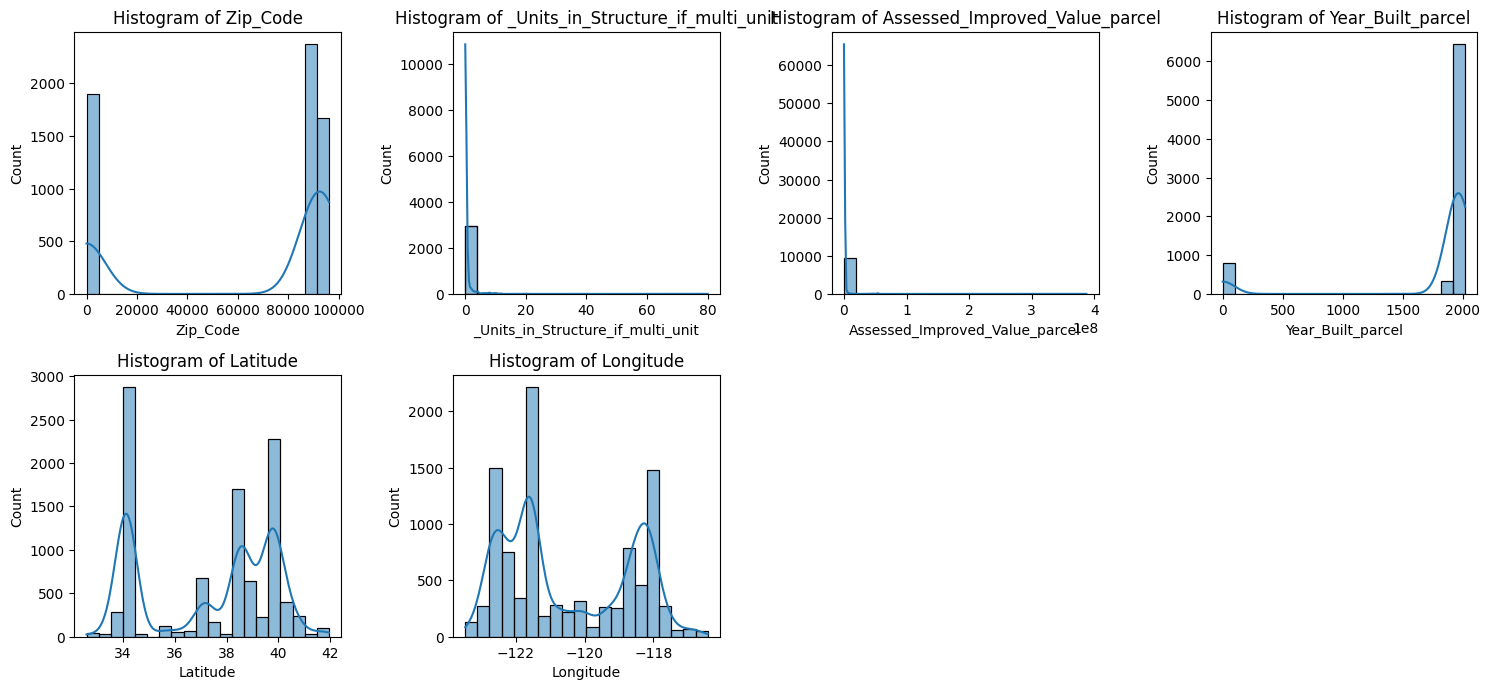

In [48]:
# Continuous (float64) columns
continuous_cols = df.select_dtypes(include=['float64']).columns

# Plot histograms for continuous features
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 4, i) 
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Histogram of {col}")
    plt.tight_layout()

plt.show()

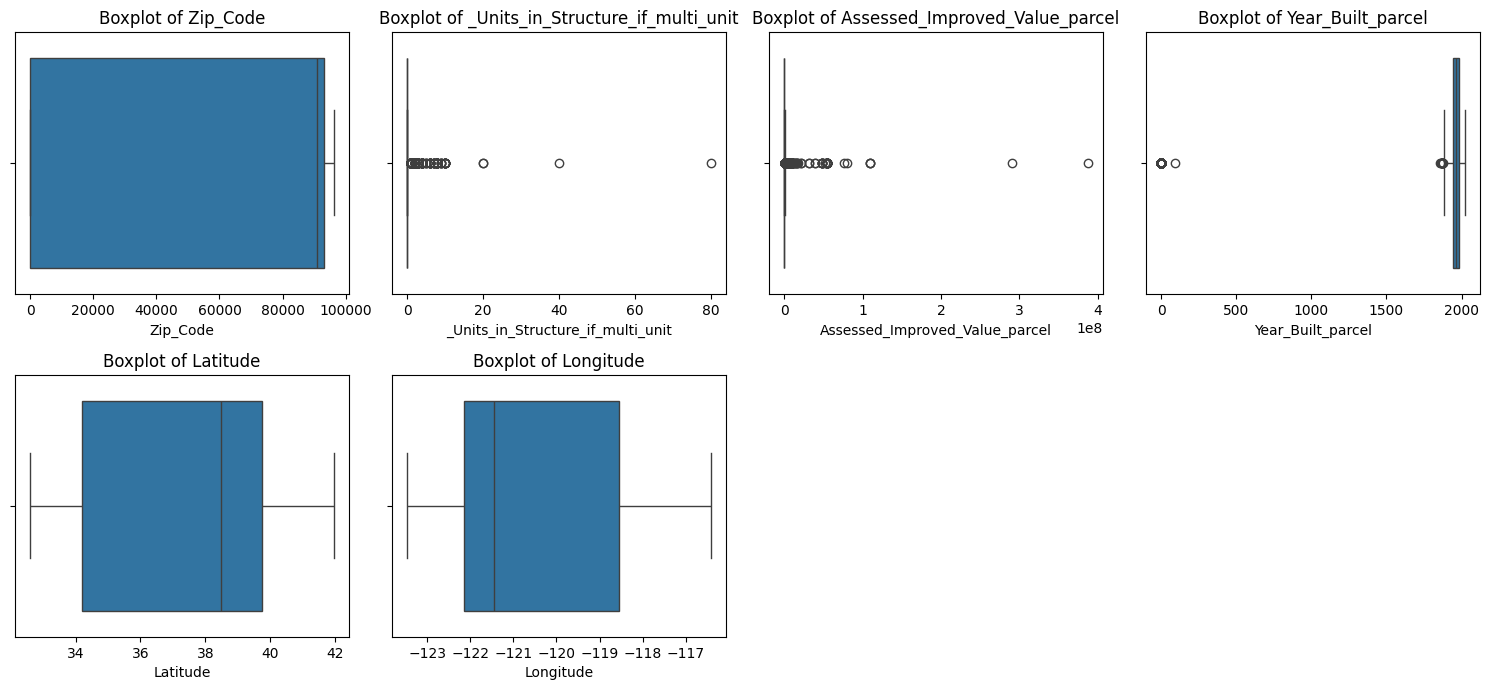

In [49]:
# Plot box plots for continuous features, filtering out NaN or single unique value columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols, 1):
    if df[col].nunique() > 1: 
        plt.subplot(3, 4, i)
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.tight_layout()

plt.show()


## **PART 2**


### Data Quality Plan

This part looks more closely for data understanding. There are proposed different ways how to fix missing values or deal with columns. To obtain a good observation, firstly a copy of dataset will be loaded with a new name, which will be the new modified dataset. This dataset is exactly the same as for part 1, it is a copy to display different changes.

In [50]:
df_2 = pd.read_csv('./cal-wildfires-24231301-modified.csv')

In [51]:
# Clean column names: Remove leading/trailing spaces, replace spaces with underscores, and remove special characters
df_2.columns = df.columns.str.strip().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)

ValueError: Length mismatch: Expected axis has 24 elements, new values have 33 elements

In [52]:
# Select categorical columns based on known categorical features
categorical_columns = df_2[['_Damage', '_Street_Name', '_Street_Number', '_Street_Type_eg_road_drive_lane_etc', '_City', 'State', 'Zip_Code', '_CAL_FIRE_Unit',
                          'County', 'Community', 'Hazard_Type', 'Structure_Defense_Actions_Taken',
                          'Structure_Category', '_Roof_Construction', '_Eaves',
                          '_Vent_Screen', '_Exterior_Siding', '_Window_Pane', '_DeckPorch_On_Grade',
                          '_DeckPorch_Elevated', '_Patio_CoverCarport_Attached_to_Structure',
                          '_Fence_Attached_to_Structure', 'Site_Address_parcel']]

# These columns were chosen as categorical because they contain descriptive values 
# representing different classes rather than numerical data.

# Convert selected columns to categorical data type
for column in categorical_columns:
    df_2[column] = df_2[column].astype('category')

# Select continuous features based on numeric data types
continuous_features = df_2.select_dtypes(['int64', 'float64']).columns  


KeyError: "['State', 'Zip_Code', 'County', 'Community', 'Hazard_Type', 'Structure_Defense_Actions_Taken', 'Site_Address_parcel'] not in index"

In [ ]:
# Turn the feature 'ID' from 'int64' to 'category' type
df_2['OBJECTID'] = df_2['OBJECTID'].astype('category')

In [ ]:
# displaying all columns at once
pd.set_option('display.max_columns', None)

### 1. Dropping out columns


In this dataset, there are some columns that have many missing values, or they are already part of different columns. 
- Zip code, County and Community, they all have many missing values but they can be descriped as Longitude and Latitude which has no missing values.
- Structure defense actions taken, Units in Structure, Distance from propane tank to building, Distance residence to utility structure and Site address parcel - all of these have more than 75% missing values. Therefore there is no point of keeping these for observation of this dataset.
- State and Fire Hazard will be dropped as well, as they indicate the same constant information (State - CA, Fire Hazard - Fire)

In [53]:
# Drop 'Structure_Defense_Actions_Taken' (72% missing)
df_2.drop(columns=['Structure_Defense_Actions_Taken'], inplace=True)

# Drop 'Community' (57% missing)
df_2.drop(columns=['Community'], inplace=True)

# Drop 'Zip_Code' (40% missing) 
df_2.drop(columns=['Zip_Code'], inplace=True)

# Drop 'Units in Structure' (70% missing)
df_2.drop(columns=['_Units_in_Structure_if_multi_unit'], inplace=True)

# Drop 'Distance from propane tank to building' (81% missing)
df_2.drop(columns=['Distance__Propane_Tank_to_Structure'], inplace=True)

# Drop 'Distance residence to utility structure' (85% missing)
df_2.drop(columns=['Distance__Residence_to_UtilityMisc_Structure_gt_120_SQFT'], inplace=True)

# Drop 'County'
df_2.drop(columns=['County'], inplace=True)

# Drop 'Site_Address_parcel' 
df_2.drop(columns=['Site_Address_parcel'], inplace=True)

# Drop 'Hazard_Type'
df_2.drop(columns=['Hazard_Type'], inplace=True)

# Drop 'State' 
df_2.drop(columns=['State'], inplace=True)

KeyError: "['Structure_Defense_Actions_Taken'] not found in axis"

In [54]:
# Drop 'ObjectID' 
df_2.drop(columns=['OBJECTID'], inplace=True)

In [ ]:
#confirm changes
df_2.shape

(10000, 23)

In [ ]:
df_2.head(5)

,OBJECTID,_Damage,_Street_Number,_Street_Name,_Street_Type_eg_road_drive_lane_etc,_City,_CAL_FIRE_Unit,Incident_Start_Date,_Structure_Type,Structure_Category,_Roof_Construction,_Eaves,_Vent_Screen,_Exterior_Siding,_Window_Pane,_DeckPorch_On_Grade,_DeckPorch_Elevated,_Patio_CoverCarport_Attached_to_Structure,_Fence_Attached_to_Structure,Assessed_Improved_Value_parcel,Year_Built_parcel,Latitude,Longitude
0,1249,Destroyed (>50%),28615.0,North Highway 101,Other,Willits,MEU,9/7/2020 12:00:00 AM,Utility Misc Structure,Other Minor Structure,Unknown,No Eaves,No Vents,Wood,Single Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,NaN,NaN,39.484,-123.360
1,114904,No Damage,1534.0,Morada,Place,Altadena,LAC,1/7/2025 8:02:01 AM,Utility Misc Structure,Other Minor Structure,Tile,No Eaves,No Vents,Stucco Brick Cement,Single Pane,Masonry/Concrete,No Deck/Porch,No Patio Cover/Carport,Combustible,4.780e+05,NaN,34.179,-118.119
2,33819,Destroyed (>50%),1852.0,Merrill,Road,Paradise Northeast B,BTU,11/8/2018 12:00:00 AM,Single Family Residence Single Story,Single Residence,Asphalt,Enclosed,"Mesh Screen <= 1/8""""",Ignition Resistant,Multi Pane,Masonry/Concrete,Wood,Combustible,Combustible,8.210e+04,1977.0,39.781,-121.574
3,49965,Destroyed (>50%),29685.0,Cuthbert,Road,Malibu,LAC,11/8/2018 12:00:00 AM,Utility Misc Structure,Other Minor Structure,Metal,No Eaves,No Vents,Ignition Resistant,Unknown,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,1.004e+06,1978.0,34.034,-118.821
4,55152,No Damage,NaN,NaN,NaN,Unincorporated,BTU,11/8/2018 12:00:00 AM,Single Family Residence Single Story,Single Residence,,,,,,,,,NaN,2.591e+05,2000.0,39.677,-121.571


### 2. No missing data


- These columns are not missing any data, therefore no modifications wil be made.
- Longitude, Latitude, Structure Category, Structure Type, Damage, Cal Fire Unit


### 3. Replacing categorical columns

Replacing categorical columns that have NaN values with their mode. These columns are needed and will be good for data analysis, it is better approach to fill out the missing data with mode.
- Roof construction, eaves, vent screen, exterior siding, window pane, deck/porch on grade/elevated, patio attached, fence attached

In [ ]:
# List of columns to handle
columns_to_replace = [
    '_Roof_Construction',
    '_Eaves',
    '_Vent_Screen',
    '_Exterior_Siding',
    '_Window_Pane',
    '_DeckPorch_On_Grade',
    '_DeckPorch_Elevated',
    '_Patio_CoverCarport_Attached_to_Structure',
    '_Fence_Attached_to_Structure'
]

# Loop through each column
for column in columns_to_replace:
    # Check if the column is categorical
    if df_2[column].dtype.name == 'category':
        # Convert categorical to regular object temporarily for replacement
        df_2[column] = df_2[column].astype(str)

        # Replace 'Unknown' with NaN for categorical columns
        df_2[column] = df_2[column].replace('Unknown', pd.NA)

        # Convert back to categorical after replacement (if you want to keep it categorical)
        df_2[column] = df_2[column].astype('category')
    else:
        # For non-categorical columns, replace 'Unknown' with NaN
        df_2[column] = df_2[column].replace('Unknown', pd.NA)

    # Fill NaN values with the mode (most common value)
    df_2[column] = df_2[column].fillna(df_2[column].mode()[0])

# Verify changes
print(df_2[columns_to_replace].head())


  _Roof_Construction    _Eaves          _Vent_Screen     _Exterior_Siding  \
0            Asphalt  No Eaves              No Vents                 Wood   
1               Tile  No Eaves              No Vents  Stucco Brick Cement   
2            Asphalt  Enclosed  Mesh Screen <= 1/8""   Ignition Resistant   
3              Metal  No Eaves              No Vents   Ignition Resistant   
4                                                                           

  _Window_Pane _DeckPorch_On_Grade _DeckPorch_Elevated  \
0  Single Pane       No Deck/Porch       No Deck/Porch   
1  Single Pane    Masonry/Concrete       No Deck/Porch   
2   Multi Pane    Masonry/Concrete                Wood   
3   Multi Pane       No Deck/Porch       No Deck/Porch   
4                                                        

  _Patio_CoverCarport_Attached_to_Structure _Fence_Attached_to_Structure  
0                    No Patio Cover/Carport                     No Fence  
1                    No Patio Cover/Ca

In [ ]:
# Replace string 'nan' with actual NaN value
df_2['_Fence_Attached_to_Structure'] = df_2['_Fence_Attached_to_Structure'].replace('nan', pd.NA)

# Fill NaN values with the mode (most frequent value) or another value
df_2['_Fence_Attached_to_Structure'] = df_2['_Fence_Attached_to_Structure'].fillna(df_2['_Fence_Attached_to_Structure'].mode()[0])


C:\Users\ragul\AppData\Local\Temp\ipykernel_7880\1888237880.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_2['_Fence_Attached_to_Structure'] = df_2['_Fence_Attached_to_Structure'].replace('nan', pd.NA)


In [ ]:
# Verify changes (optional)
print(df_2[columns_to_replace].head())

  _Roof_Construction    _Eaves          _Vent_Screen     _Exterior_Siding  \
0            Asphalt  No Eaves              No Vents                 Wood   
1               Tile  No Eaves              No Vents  Stucco Brick Cement   
2            Asphalt  Enclosed  Mesh Screen <= 1/8""   Ignition Resistant   
3              Metal  No Eaves              No Vents   Ignition Resistant   
4                                                                           

  _Window_Pane _DeckPorch_On_Grade _DeckPorch_Elevated  \
0  Single Pane       No Deck/Porch       No Deck/Porch   
1  Single Pane    Masonry/Concrete       No Deck/Porch   
2   Multi Pane    Masonry/Concrete                Wood   
3   Multi Pane       No Deck/Porch       No Deck/Porch   
4                                                        

  _Patio_CoverCarport_Attached_to_Structure _Fence_Attached_to_Structure  
0                    No Patio Cover/Carport                     No Fence  
1                    No Patio Cover/Ca

### 4. Replacing continuous features

Replacing no values with median for continuous features.
- Assessed value parcel and Year built parcel
- Year built parcel has a lot of "0" instead the word "NaN", that is also considered for replacing it with the mean as well.

In [ ]:
# Fill missing values in 'Assessed_Improved_Value_parcel' with median
df_2['Assessed_Improved_Value_parcel'] = df_2['Assessed_Improved_Value_parcel'].fillna(df_2['Assessed_Improved_Value_parcel'].median())

In [ ]:
# Replace 0 values with NaN in 'Year_Built_parcel' since 0 is considered invalid
df_2['Year_Built_parcel'] = df_2['Year_Built_parcel'].replace(0, pd.NA)

# Fill missing values (NaN and replaced 0 values) with median
df_2['Year_Built_parcel'] = df_2['Year_Built_parcel'].fillna(df_2['Year_Built_parcel'].median())


C:\Users\ragul\AppData\Local\Temp\ipykernel_7880\3233098971.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_2['Year_Built_parcel'] = df_2['Year_Built_parcel'].fillna(df_2['Year_Built_parcel'].median())


### 5. Fill the missing values

Replace all missing words with the word "Unknown"
- Incident start date, Street number, Street name, Streety type, City

In [ ]:
# Fill missing values in 'Incident_Start_Date' with 'Unknown Date'
df_2['Incident_Start_Date'] = df_2['Incident_Start_Date'].fillna('Unknown Date')


In [ ]:
# For _Street_Number column
df_2['_Street_Number'] = df_2['_Street_Number'].cat.add_categories('Unknown')
df_2['_Street_Number'] = df_2['_Street_Number'].fillna('Unknown')

In [ ]:
#street name column
df_2['_Street_Name'] = df_2['_Street_Name'].fillna('Unknown')

In [ ]:
# For _Street_Type_eg_road_drive_lane_etc column
df_2['_Street_Type_eg_road_drive_lane_etc'] = df_2['_Street_Type_eg_road_drive_lane_etc'].cat.add_categories('Unknown')
df_2['_Street_Type_eg_road_drive_lane_etc'] = df_2['_Street_Type_eg_road_drive_lane_etc'].fillna('Unknown')

In [ ]:
# For _City column
df_2['_City'] = df_2['_City'].cat.add_categories('Unknown')
df_2['_City'] = df_2['_City'].fillna('Unknown')

Checking all the columns are correct and up to date

In [ ]:
df_2.head(10)

,OBJECTID,_Damage,_Street_Number,_Street_Name,_Street_Type_eg_road_drive_lane_etc,_City,_CAL_FIRE_Unit,Incident_Start_Date,_Structure_Type,Structure_Category,_Roof_Construction,_Eaves,_Vent_Screen,_Exterior_Siding,_Window_Pane,_DeckPorch_On_Grade,_DeckPorch_Elevated,_Patio_CoverCarport_Attached_to_Structure,_Fence_Attached_to_Structure,Assessed_Improved_Value_parcel,Year_Built_parcel,Latitude,Longitude
0,1249,Destroyed (>50%),28615.0,North Highway 101,Other,Willits,MEU,9/7/2020 12:00:00 AM,Utility Misc Structure,Other Minor Structure,Asphalt,No Eaves,No Vents,Wood,Single Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,1.599e+05,1966.0,39.484,-123.360
1,114904,No Damage,1534.0,Morada,Place,Altadena,LAC,1/7/2025 8:02:01 AM,Utility Misc Structure,Other Minor Structure,Tile,No Eaves,No Vents,Stucco Brick Cement,Single Pane,Masonry/Concrete,No Deck/Porch,No Patio Cover/Carport,Combustible,4.780e+05,1966.0,34.179,-118.119
2,33819,Destroyed (>50%),1852.0,Merrill,Road,Paradise Northeast B,BTU,11/8/2018 12:00:00 AM,Single Family Residence Single Story,Single Residence,Asphalt,Enclosed,"Mesh Screen <= 1/8""""",Ignition Resistant,Multi Pane,Masonry/Concrete,Wood,Combustible,Combustible,8.210e+04,1977.0,39.781,-121.574
3,49965,Destroyed (>50%),29685.0,Cuthbert,Road,Malibu,LAC,11/8/2018 12:00:00 AM,Utility Misc Structure,Other Minor Structure,Metal,No Eaves,No Vents,Ignition Resistant,Multi Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,1.004e+06,1978.0,34.034,-118.821
4,55152,No Damage,Unknown,Unknown,Unknown,Unincorporated,BTU,11/8/2018 12:00:00 AM,Single Family Residence Single Story,Single Residence,,,,,,,,,No Fence,2.591e+05,2000.0,39.677,-121.571
5,30010,Destroyed (>50%),1757.0,Whitiker,Road,Paradise Northeast B,BTU,11/8/2018 12:00:00 AM,Single Family Residence Single Story,Single Residence,Asphalt,Enclosed,"Mesh Screen <= 1/8""""",Combustible,Multi Pane,Masonry/Concrete,No Deck/Porch,Combustible,No Fence,6.544e+04,1957.0,39.776,-121.578
6,7318,Destroyed (>50%),34337.0,Shaver Springs,Road,Unknown,FKU,9/4/2020 12:00:00 AM,Utility Misc Structure,Other Minor Structure,Metal,No Eaves,No Vents,Wood,No Windows,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,1.833e+03,1966.0,37.049,-119.367
7,78745,No Damage,0.0,Stuart Gap,Road,Platina,TGU,7/29/2021 12:00:00 AM,Utility Misc Structure,Other Minor Structure,Asphalt,Unenclosed,"Mesh Screen > 1/8""""",Stucco Brick Cement,Multi Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,1.599e+05,1966.0,40.235,-122.926
8,98658,No Damage,39.0,Mt Baldy,Road,Mt Baldy,BDU,9/8/2024 12:00:00 AM,Single Family Residence Single Story,Single Residence,Asphalt,Unenclosed,"Mesh Screen > 1/8""""",Wood,Multi Pane,Masonry/Concrete,No Deck/Porch,Combustible,Combustible,2.450e+05,1958.0,34.237,-117.659
9,53781,No Damage,Unknown,Unknown,Unknown,Unincorporated,BTU,11/8/2018 12:00:00 AM,Single Family Residence Multi Story,Single Residence,,,,,,,,,No Fence,1.500e+04,1966.0,39.770,-121.499


In [ ]:
df_2.dtypes

OBJECTID                                     category
_Damage                                      category
_Street_Number                               category
_Street_Name                                 category
_Street_Type_eg_road_drive_lane_etc          category
_City                                        category
_CAL_FIRE_Unit                               category
Incident_Start_Date                            object
_Structure_Type                                object
Structure_Category                           category
_Roof_Construction                           category
_Eaves                                       category
_Vent_Screen                                 category
_Exterior_Siding                             category
_Window_Pane                                 category
_DeckPorch_On_Grade                          category
_DeckPorch_Elevated                          category
_Patio_CoverCarport_Attached_to_Structure    category
_Fence_Attached_to_Structure

In [55]:
df_2.to_csv('./cal-wildfires-24231301-modified.csv')

In [56]:
df_2.head(5)

,Unnamed: 0,_Damage,_Street_Number,_Street_Name,_Street_Type_eg_road_drive_lane_etc,_City,_CAL_FIRE_Unit,Incident_Start_Date,_Structure_Type,Structure_Category,_Roof_Construction,_Eaves,_Vent_Screen,_Exterior_Siding,_Window_Pane,_DeckPorch_On_Grade,_DeckPorch_Elevated,_Patio_CoverCarport_Attached_to_Structure,_Fence_Attached_to_Structure,Assessed_Improved_Value_parcel,Year_Built_parcel,Latitude,Longitude
0,0,Destroyed (>50%),28615.0,North Highway 101,Other,Willits,MEU,9/7/2020 12:00:00 AM,Utility Misc Structure,Other Minor Structure,Asphalt,No Eaves,No Vents,Wood,Single Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,1.599e+05,1966.0,39.484,-123.360
1,1,No Damage,1534.0,Morada,Place,Altadena,LAC,1/7/2025 8:02:01 AM,Utility Misc Structure,Other Minor Structure,Tile,No Eaves,No Vents,Stucco Brick Cement,Single Pane,Masonry/Concrete,No Deck/Porch,No Patio Cover/Carport,Combustible,4.780e+05,1966.0,34.179,-118.119
2,2,Destroyed (>50%),1852.0,Merrill,Road,Paradise Northeast B,BTU,11/8/2018 12:00:00 AM,Single Family Residence Single Story,Single Residence,Asphalt,Enclosed,"Mesh Screen <= 1/8""""",Ignition Resistant,Multi Pane,Masonry/Concrete,Wood,Combustible,Combustible,8.210e+04,1977.0,39.781,-121.574
3,3,Destroyed (>50%),29685.0,Cuthbert,Road,Malibu,LAC,11/8/2018 12:00:00 AM,Utility Misc Structure,Other Minor Structure,Metal,No Eaves,No Vents,Ignition Resistant,Multi Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,1.004e+06,1978.0,34.034,-118.821
4,4,No Damage,Unknown,Unknown,Unknown,Unincorporated,BTU,11/8/2018 12:00:00 AM,Single Family Residence Single Story,Single Residence,,,,,,,,,No Fence,2.591e+05,2000.0,39.677,-121.571


## **PART 3**

### Exploring relationships between different pairs

This part will look closely to different columns/features and how they correlate to each other. After examining features, the main question will be answered - After rebuilting this area, what structure of the houses should be used to predict less risk of damage in the future? What did cause the damage of wildfire in CA and how can it be prevented in the future?
- Damage column in this dataset only has 2 features: "No Damage" or "Damage > 50%"


Different columns were chosen for examination of this part. This part is also divided into 3 subparts: Continuous vs Continuous, Continuous vs Categorical, Categorical vs Categorical

### Categorical vs Categorical

Exterior siding vs damage level
- From the graph, it can be deducted that metal, stucco brick, cement, wood, and vinyl were more resistant materials than combustible, fire and ignition resistant.

In [ ]:

df_2.groupby("_Exterior_Siding")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\3495195716.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2.groupby("_Exterior_Siding")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


_Damage,Destroyed (>50%),No Damage
_Exterior_Siding,,
,0.33,99.67
Combustible,98.48,1.52
Fire Resistant,96.02,3.98
Ignition Resistant,99.18,0.82
Metal,49.85,50.15
Other,47.22,52.78
Stucco Brick Cement,47.62,52.38
Stucco/Brick/Cement,72.73,27.27
Vinyl,37.86,62.14


C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\4270594473.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  siding_damage = df_2.groupby("_Exterior_Siding")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


<Figure size 1000x600 with 0 Axes>

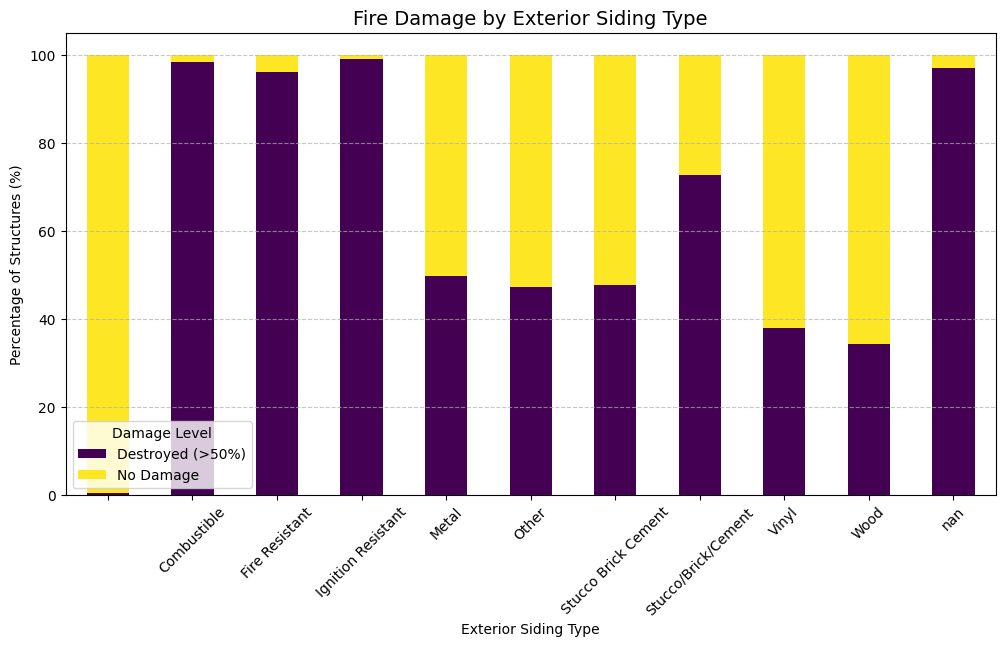

In [ ]:
plt.figure(figsize=(10,6))
siding_damage = df_2.groupby("_Exterior_Siding")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)
siding_damage.plot(kind="bar", stacked=True, colormap="viridis", figsize=(12,6))

plt.title("Fire Damage by Exterior Siding Type", fontsize=14)
plt.ylabel("Percentage of Structures (%)")
plt.xlabel("Exterior Siding Type")
plt.legend(title="Damage Level")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Window pane vs damage
- In this graph, it can be deducted, that buildings with no windows had been the least destroyed.
- On the other hand, more windows are showing more damage

In [ ]:
# window pane type vs fire damage
df_2.groupby("_Window_Pane")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)

C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\1453480809.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2.groupby("_Window_Pane")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


_Damage,Destroyed (>50%),No Damage
_Window_Pane,,
,0.33,99.67
Multi Pane,59.58,40.42
No Windows,53.57,46.43
Single Pane,61.30,38.70
nan,97.26,2.74


C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\586854961.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  window_damage = df_2.groupby("_Window_Pane")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


<Figure size 1200x600 with 0 Axes>

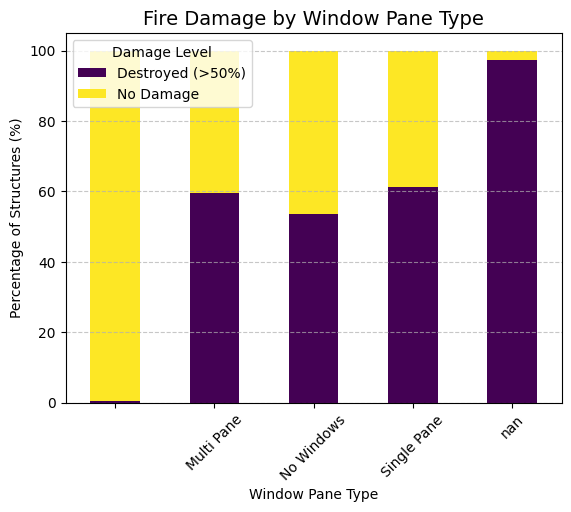

In [ ]:
window_damage = df_2.groupby("_Window_Pane")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)

# Plotting the data as a stacked bar chart
plt.figure(figsize=(12, 6))
window_damage.plot(kind="bar", stacked=True, colormap="viridis")

# Adding title, labels, and legend
plt.title("Fire Damage by Window Pane Type", fontsize=14)
plt.ylabel("Percentage of Structures (%)")
plt.xlabel("Window Pane Type")
plt.legend(title="Damage Level")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)


Fence attached to the building vs damage
- If buildings had fence, there were more likely to not be destroyed.
- Assumption made about this is that fire destroyed fences and did not get to buildings.

In [ ]:
# Fence Attached to structure x damage33
df_2.groupby("_Fence_Attached_to_Structure")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)

C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\2960661889.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2.groupby("_Fence_Attached_to_Structure")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


_Damage,Destroyed (>50%),No Damage
_Fence_Attached_to_Structure,,
Combustible,46.15,53.85
No Fence,59.26,40.74
Non Combustible,61.57,38.43


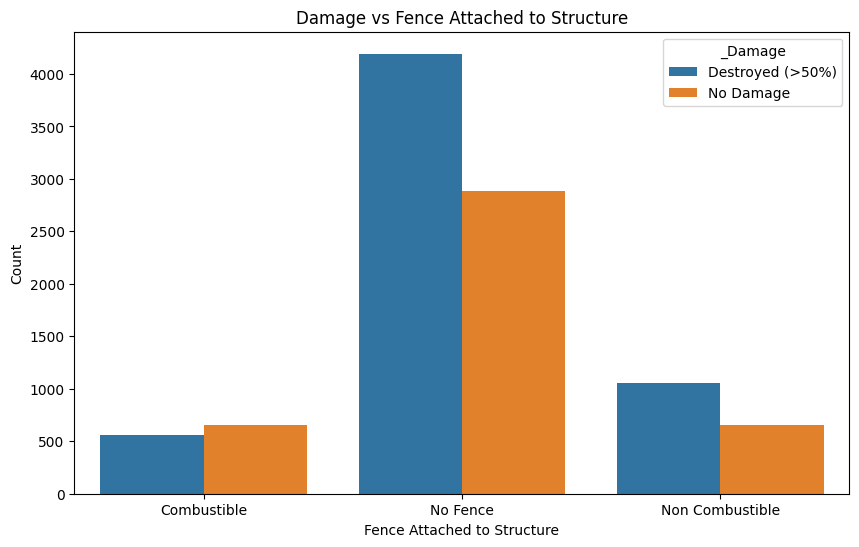

In [ ]:
# Damage vs Fence Attached to Structure
plt.figure(figsize=(10, 6))
sns.countplot(x='_Fence_Attached_to_Structure', hue='_Damage', data=df_2)
plt.title('Damage vs Fence Attached to Structure')
plt.xlabel('Fence Attached to Structure')
plt.ylabel('Count')
plt.show()

City vs damage
- In these features graphs and ploting is not ideal, as there is 10000 rows.
- These features are look at see the correlation between different cities. In this analysis, it is nice to look at and take it into consideration. However, to plot that many data is not ideal.

In [ ]:
# city vs damage
df_2.groupby("_City")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\2659557469.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2.groupby("_City")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


_Damage,Destroyed (>50%),No Damage
_City,,
,50.00,50.00
Agoura Hills,100.00,0.00
Aguanga,16.67,83.33
Alpine,100.00,0.00
Altadena,66.11,33.89
...,...,...
Yucaipa,0.00,100.00
Yucaipa,0.00,100.00
Zenia,0.00,100.00


Multi-unit structures vs damage
- Single residences did not survive the fire.
- On the other hand, bigger and non residential buildings had better changes of surviving.

In [ ]:
# multi-unit structures vs fire damage
df_2.groupby("Structure_Category")["_Damage"].value_counts().unstack()

C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\2669932372.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2.groupby("Structure_Category")["_Damage"].value_counts().unstack()


_Damage,Destroyed (>50%),No Damage
Structure_Category,,
Infrastructure,17,46
Mixed Commercial/Residential,12,16
Multiple Residence,44,117
Nonresidential Commercial,176,244
Other Minor Structure,1599,1098
Single Residence,3959,2672


C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\2371671340.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  damage_counts = df_2.groupby("Structure_Category")["_Damage"].value_counts().unstack()


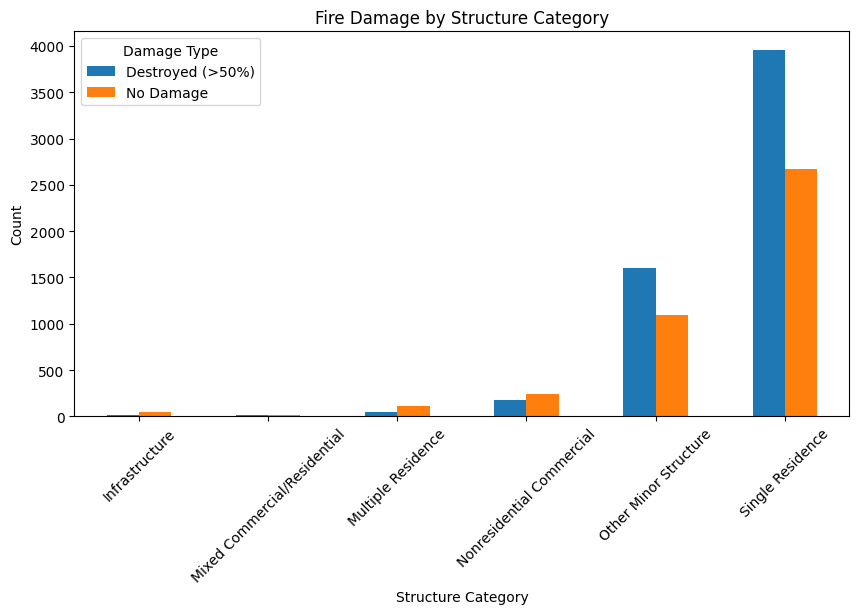

In [ ]:
damage_counts = df_2.groupby("Structure_Category")["_Damage"].value_counts().unstack()
damage_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Fire Damage by Structure Category")
plt.ylabel("Count")
plt.xlabel("Structure Category")
plt.xticks(rotation=45)
plt.legend(title="Damage Type")
plt.show()


Structure Types vs Damage
- The bigger buildings, the more they survived the fire
- Mobile homes, home residences had a high proportion of being destroyed
- On the other hand churches, hospitals, or schools were not affected that much by the fire

In [ ]:

df_2.groupby('_Structure_Type')['_Damage'].value_counts(normalize=True).unstack().mul(100).round(2)


_Damage,Destroyed (>50%),No Damage
_Structure_Type,,
Church,16.67,83.33
Commercial Building Multi Story,24.14,75.86
Commercial Building Single Story,48.14,51.86
Hospital,0.00,100.00
Infrastructure,26.98,73.02
Mixed Commercial/Residential,42.86,57.14
Mobile Home Double Wide,82.12,17.88
Mobile Home Single Wide,80.58,19.42
Mobile Home Triple Wide,87.18,12.82


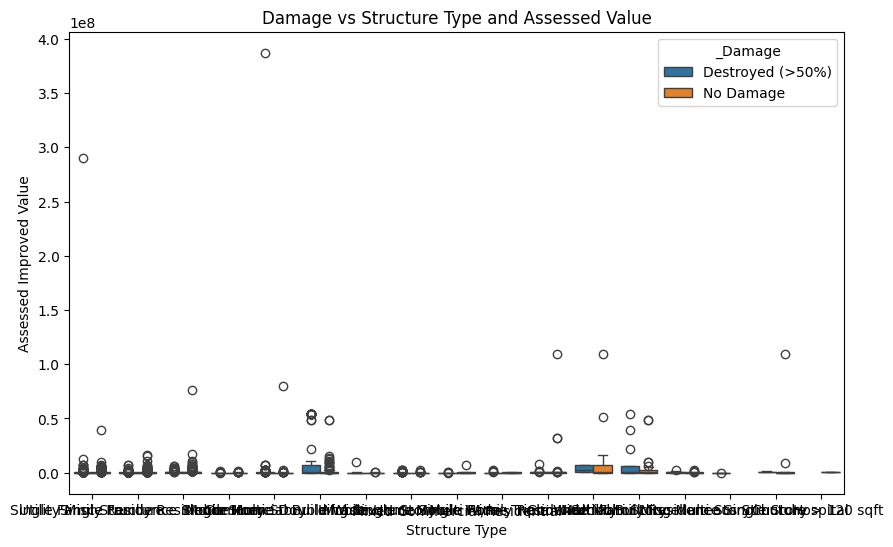

In [ ]:
category_damage_table = df_2.groupby('_Structure_Type')['_Damage'].value_counts(normalize=True).unstack().mul(100).round(2)
plt.figure(figsize=(10, 6))
sns.boxplot(x='_Structure_Type', y='Assessed_Improved_Value_parcel', hue='_Damage', data=df)
plt.title('Damage vs Structure Type and Assessed Value')
plt.xlabel('Structure Type')
plt.ylabel('Assessed Improved Value')
plt.show()

### Continuous vs Continous

Property value vs damage
- Bigger and more valuable buildings had better chances of survival
- Assumption made could be, that more valuable buildings had better materials, therefore they survived more.

In [ ]:

df_2.groupby("_Damage")["Assessed_Improved_Value_parcel"].describe()

C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\2612902763.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2.groupby("_Damage")["Assessed_Improved_Value_parcel"].describe()


,count,mean,std,min,25%,50%,75%,max
_Damage,,,,,,,,
Destroyed (>50%),5807.0,677326.357,7.365e+06,0.0,66300.0,150107.0,288545.0,3.873e+08
No Damage,4193.0,645034.628,4.035e+06,0.0,91210.0,172227.0,374436.0,1.095e+08


C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\3706066617.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="_Damage", y="Assessed_Improved_Value_parcel", data=df_2, palette="coolwarm")


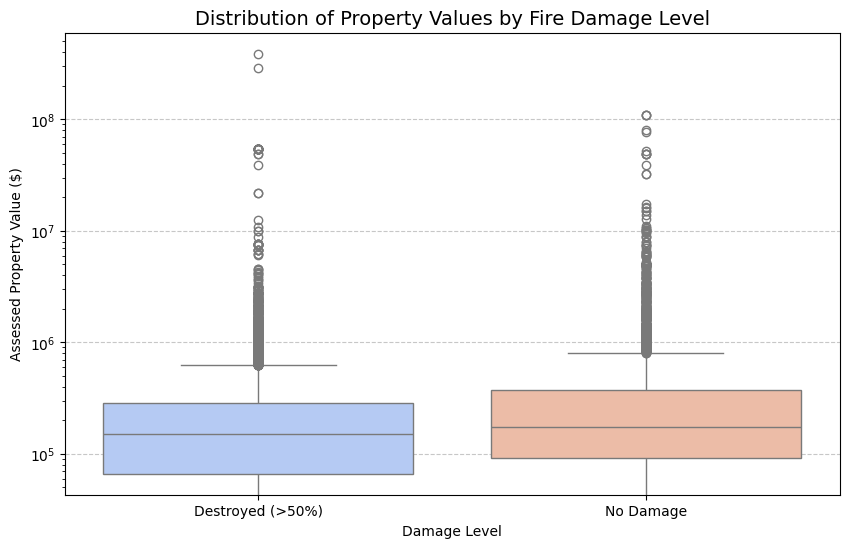

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x="_Damage", y="Assessed_Improved_Value_parcel", data=df_2, palette="coolwarm")

plt.title("Distribution of Property Values by Fire Damage Level", fontsize=14)
plt.xlabel("Damage Level")
plt.ylabel("Assessed Property Value ($)")
plt.yscale("log")  # Log scale for better visualization
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Year built vs damage
- It can be seen, that older buildings did not survive
- Younger buildings had better chances of survival

In [ ]:

df_2.groupby("_Damage")["Year_Built_parcel"].describe()


C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\1891157640.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2.groupby("_Damage")["Year_Built_parcel"].describe()


,count,mean,std,min,25%,50%,75%,max
_Damage,,,,,,,,
Destroyed (>50%),5807.0,1963.471,32.552,89.0,1953.0,1966.0,1974.0,2020.0
No Damage,4193.0,1967.586,22.957,1860.0,1959.0,1966.0,1980.0,2022.0


C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\2434188016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="_Damage", y="Year_Built_parcel", data=df_2, palette="Set2")


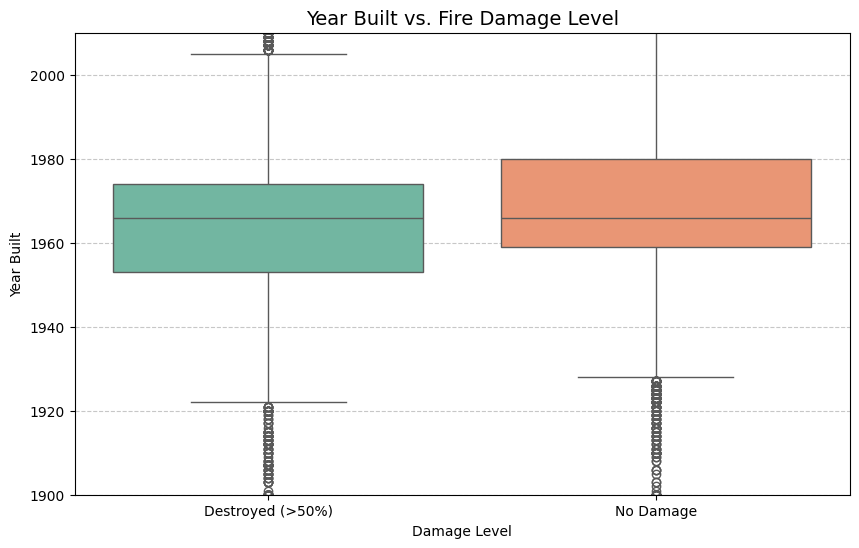

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="_Damage", y="Year_Built_parcel", data=df_2, palette="Set2")
plt.title("Year Built vs. Fire Damage Level", fontsize=14)
plt.xlabel("Damage Level")
plt.ylabel("Year Built")
plt.ylim(1900, 2010)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Porch on grade vs damage
- Very similar can be seen as in fences dataset. If there was a porch, the damage was less than if there was no porch.
- Composite porches were better than concrete and wooden.
- Assumption made is that if there was a porch, the fire would not go further to the building

In [ ]:
# Deck/Porch on Grade and damage level
df_2.groupby("_DeckPorch_On_Grade")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)

C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\2196469938.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2.groupby("_DeckPorch_On_Grade")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


_Damage,Destroyed (>50%),No Damage
_DeckPorch_On_Grade,,
,78.43,21.57
Composite,20.51,79.49
Masonry/Concrete,49.15,50.85
No Deck/Porch,61.78,38.22
Wood,53.39,46.61


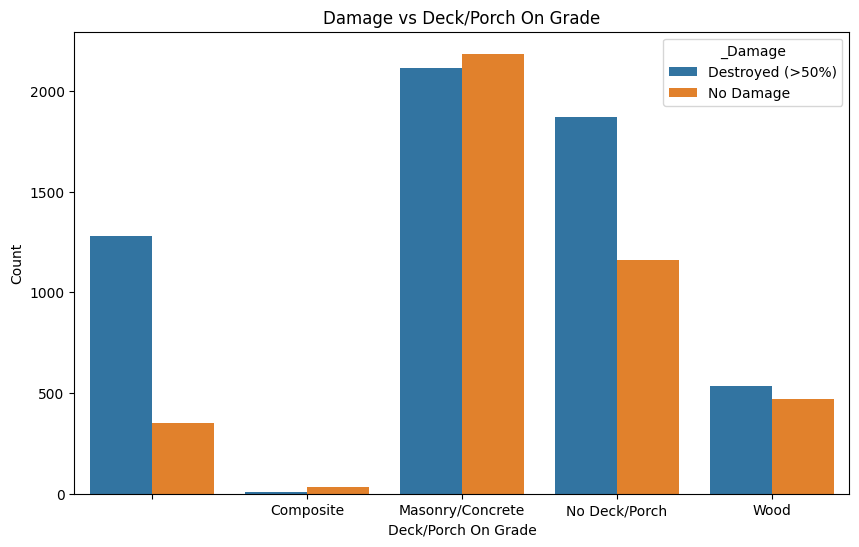

In [ ]:

plt.figure(figsize=(10, 6))
sns.countplot(x='_DeckPorch_On_Grade', hue='_Damage', data=df_2)
plt.title('Damage vs Deck/Porch On Grade')
plt.xlabel('Deck/Porch On Grade')
plt.ylabel('Count')
plt.show()

### Categorical vs Continuous

Roof type vs damage
- Interestingly, combustile and fire resistant roofs were destroyed on 95%
- Metal, concrete, and asphalt roofs were not that bad, if 50% of survival

In [ ]:
# roof type and damage level
df_2.groupby("_Roof_Construction")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)

C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\3893370111.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2.groupby("_Roof_Construction")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


_Damage,Destroyed (>50%),No Damage
_Roof_Construction,,
,0.33,99.67
Asphalt,57.67,42.33
Combustible,98.13,1.87
Concrete,47.19,52.81
Fire Resistant,96.53,3.47
Metal,53.29,46.71
Other,53.85,46.15
Tile,37.96,62.04
Wood,66.10,33.90


C:\Users\ragul\AppData\Local\Temp\ipykernel_8364\4145433375.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roof_damage = df_2.groupby("_Roof_Construction")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)


<Figure size 1000x600 with 0 Axes>

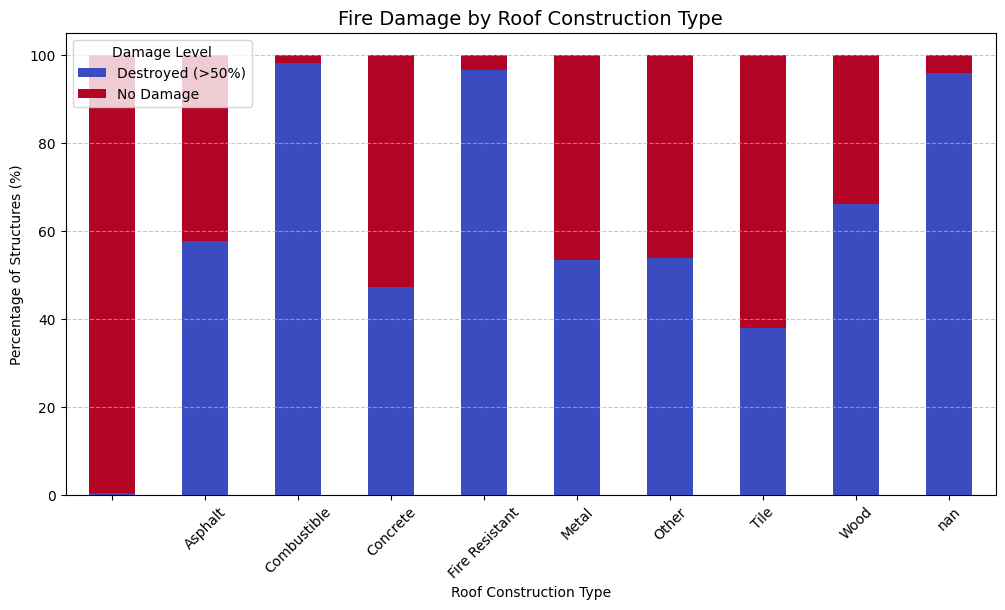

In [ ]:

plt.figure(figsize=(10,6))
roof_damage = df_2.groupby("_Roof_Construction")["_Damage"].value_counts(normalize=True).unstack().mul(100).round(2)
roof_damage.plot(kind="bar", stacked=True, colormap="coolwarm", figsize=(12,6))

plt.title("Fire Damage by Roof Construction Type", fontsize=14)
plt.ylabel("Percentage of Structures (%)")
plt.xlabel("Roof Construction Type")
plt.legend(title="Damage Level")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Plot for geographic location

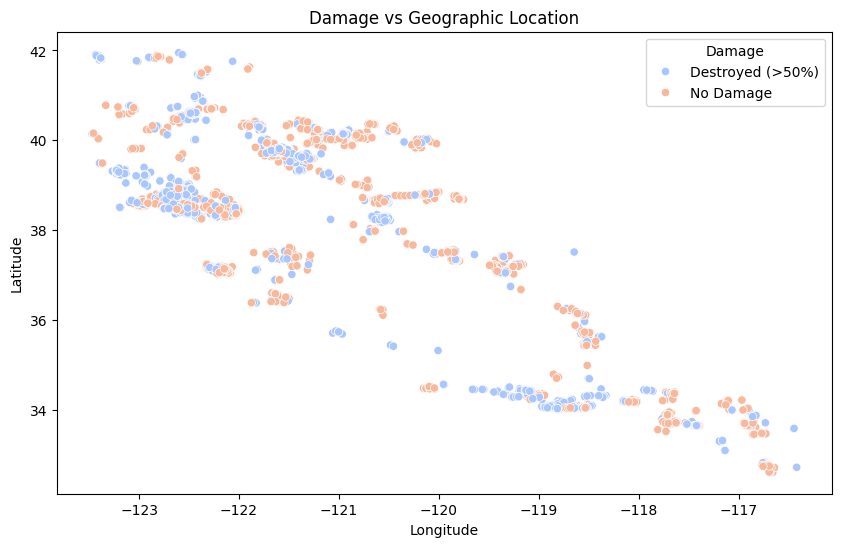

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='_Damage', palette='coolwarm', data=df_2, marker='o')
plt.title('Damage vs Geographic Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Damage')
plt.show()


Correlation matrix plot heatmap

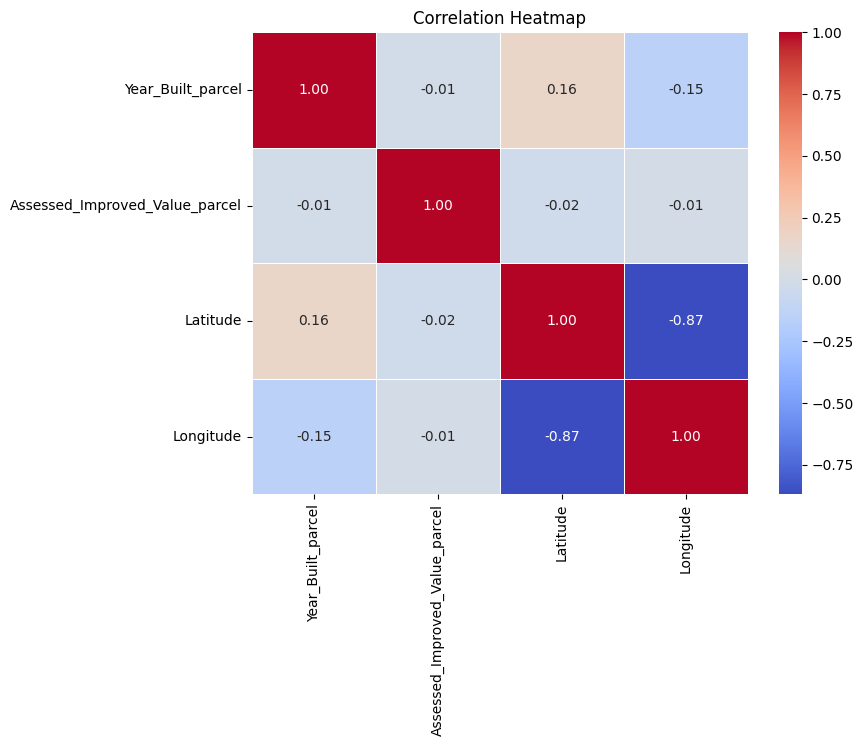

In [ ]:
continuous_features = ['Year_Built_parcel', 'Assessed_Improved_Value_parcel', 'Latitude', 'Longitude']
corr_matrix = df_2[continuous_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


### Discussion of the findings

Small parts of findings were noted below each pair relationship. They can be put down into one main finding.

There is strong correlation between the different structures of the building - roof construction, eaves, exterior siding, or if there were windows presented or not. It is shown that more expensive buildings had better structures, therefore they survived the fire more than simplier buildings. Also, if there was patio, fence or porch presented and attached to the building, the building was more likely to survive. The year of build is linked to the damage as well, however, in this analysis it is not showing us much about how to structure buildings in the future. It is obvious that older buildings had harder time to survive the fire, this can be related to the structure of the buildings. It is also shown that bigger buildings had better chance of survival. Which is presented in the damage, where the most destroyed buildings were single home structured. Assumption made, that in the future, if the buildings are going to be redone, place single home residences in the areas with less damage and have bigger and more structured buildings rebuilt in areas of the biggest damage. This can be positioned thanks to the longitudes and latitudes of damaged properties. Also with that, look at better structure of the buildings, and consider having a fence or patio attached to your building, as it can slow down the fire.

## **PART 4**

### Transform, extend or combine the existing features to create a few new features

This final part of this notebook is looking at implementation of new features that could potentially help out with further analysis.

In [ ]:
# read data from cvs into panda dataframe
df_3 = pd.read_csv('cal-wildfires-24231301-extended.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)

In [ ]:
# Clean column names: Remove leading/trailing spaces, replace spaces with underscores, and remove special characters
df_3.columns = df_3.columns.str.strip().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)

In [ ]:
# Select categorical columns based on known categorical features
categorical_columns = df_3[['_Damage', '_Street_Name', '_Street_Number', '_Street_Type_eg_road_drive_lane_etc', '_City', 'State', 'Zip_Code', '_CAL_FIRE_Unit',
                          'County', 'Community', 'Hazard_Type', 'Structure_Defense_Actions_Taken',
                          'Structure_Category', '_Roof_Construction', '_Eaves',
                          '_Vent_Screen', '_Exterior_Siding', '_Window_Pane', '_DeckPorch_On_Grade',
                          '_DeckPorch_Elevated', '_Patio_CoverCarport_Attached_to_Structure',
                          '_Fence_Attached_to_Structure', 'Site_Address_parcel']]

# These columns were chosen as categorical because they contain descriptive values 
# representing different classes rather than numerical data.

# Convert selected columns to categorical data type
for column in categorical_columns:
    df_3[column] = df_3[column].astype('category')

# Select continuous features based on numeric data types
continuous_features = df_3.select_dtypes(['int64', 'float64']).columns  


### Feature 1
Adding new column based on roof construction, exterior siding, vent screen, eaves. This code will evaluate based on materials provided if the risk of fire is low, medium or high.
- default is medium

In [ ]:
def fire_risk(row):
    risk_factors = [row['_Roof_Construction'], row['_Exterior_Siding'], row['_Vent_Screen'], row['_Eaves']]
    
    high_risk_materials = ['Wood', 'Vinyl']  # Materials that increase fire risk
    low_risk_materials = ['Masonry/Concrete', 'Fire Resistant']  # Fire-resistant materials

    risk_score = sum(1 for x in risk_factors if x in high_risk_materials)
    fire_resistant_count = sum(1 for x in risk_factors if x in low_risk_materials)

    if risk_score >= 3:
        return 'High'
    elif risk_score == 2:
        return 'Medium'
    elif fire_resistant_count >= 2:
        return 'Low'  # At least 2 features have fire-resistant materials
    else:
        return 'Medium'  # Default to medium 

df_3['Fire_Risk_Score'] = df_3.apply(fire_risk, axis=1)


### Feature 2

Creating new column, where the complexity score is created. The features evaluated are structure category, units in structure if multi unit, patio attached to structure

In [ ]:
df_3['Building_Complexity_Score'] = (
    df_3['_Units_in_Structure_if_multi_unit'].fillna(0) +
    df_3['_Patio_CoverCarport_Attached_to_Structure'].apply(lambda x: 1 if x == 'Yes' else 0)
)


### Feature 3

Creting new column, where 0 is for rural counties and areas, and 1 is for urban areas
- urban = Los Angeles, San Francisco, San Diego, Sacramento, Orange

In [ ]:
urban_counties = ['Los Angeles', 'San Francisco', 'San Diego', 'Sacramento', 'Orange']

df_3['Urban_Proximity'] = df_3['County'].apply(lambda x: 1 if x in urban_counties else 0)


In [ ]:
df_3.head(5)

,OBJECTID,_Damage,_Street_Number,_Street_Name,_Street_Type_eg_road_drive_lane_etc,_City,State,Zip_Code,_CAL_FIRE_Unit,County,Community,Incident_Start_Date,Hazard_Type,Structure_Defense_Actions_Taken,_Structure_Type,Structure_Category,_Units_in_Structure_if_multi_unit,_Roof_Construction,_Eaves,_Vent_Screen,_Exterior_Siding,_Window_Pane,_DeckPorch_On_Grade,_DeckPorch_Elevated,_Patio_CoverCarport_Attached_to_Structure,_Fence_Attached_to_Structure,Distance__Propane_Tank_to_Structure,Distance__Residence_to_UtilityMisc_Structure_gt_120_SQFT,Assessed_Improved_Value_parcel,Year_Built_parcel,Site_Address_parcel,Latitude,Longitude,Fire_Risk_Score,Building_Complexity_Score,Urban_Proximity
0,1249,Destroyed (>50%),28615.0,North Highway 101,Other,Willits,CA,NaN,MEU,Mendocino,Ryan Creek,9/7/2020 12:00:00 AM,Fire,Unknown,Utility Misc Structure,Other Minor Structure,NaN,Unknown,No Eaves,No Vents,Wood,Single Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,NaN,NaN,NaN,NaN,NaN,39.484,-123.360,Medium,0.0,0.0
1,114904,No Damage,1534.0,Morada,Place,Altadena,CA,91001.0,LAC,Los Angeles,NaN,1/7/2025 8:02:01 AM,Fire,Unknown,Utility Misc Structure,Other Minor Structure,0.0,Tile,No Eaves,No Vents,Stucco Brick Cement,Single Pane,Masonry/Concrete,No Deck/Porch,No Patio Cover/Carport,Combustible,NaN,30-50',4.780e+05,NaN,"1534 MORADA PL, ALTADENA, CA 91001",34.179,-118.119,Medium,0.0,1.0
2,33819,Destroyed (>50%),1852.0,Merrill,Road,Paradise Northeast B,CA,NaN,BTU,Butte,Paradise,11/8/2018 12:00:00 AM,Fire,Unknown,Single Family Residence Single Story,Single Residence,NaN,Asphalt,Enclosed,"Mesh Screen <= 1/8""""",Ignition Resistant,Multi Pane,Masonry/Concrete,Wood,Combustible,Combustible,NaN,<30',8.210e+04,1977.0,1852 MERRILL RD PARADISE CA 95969,39.781,-121.574,Medium,0.0,0.0
3,49965,Destroyed (>50%),29685.0,Cuthbert,Road,Malibu,CA,NaN,LAC,Los Angeles,Malibu,11/8/2018 12:00:00 AM,Fire,Unknown,Utility Misc Structure,Other Minor Structure,1.0,Metal,No Eaves,No Vents,Ignition Resistant,Unknown,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,No Fence,NaN,>50',1.004e+06,1978.0,29685 CUTHBERT RD MALIBU CA 90265,34.034,-118.821,Medium,1.0,1.0
4,55152,No Damage,NaN,NaN,NaN,Unincorporated,CA,NaN,BTU,Butte,NaN,11/8/2018 12:00:00 AM,Fire,NaN,Single Family Residence Single Story,Single Residence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.591e+05,2000.0,3445 SUNVIEW DR PARADISE CA 95969,39.677,-121.571,Medium,NaN,0.0


## **Conclussion**

This notebook was done on the analysis of different features related to the building structure and the damage made by California Fire Accident. It is showing different correlations between features of the building and areas of damage. The last part touched on possible different features that could help in the future analysis. Observings from first 2 parts are also documented in the Data Quality Report.